In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

puzzles = pd.read_csv("updated_scrape.csv")
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

In [48]:
puzzles = puzzles[~puzzles.Puzzle.isna()].copy()


In [49]:
(puzzles["Puzzle"][puzzles.Puzzle.apply(lambda x: "-" in x)]).value_counts().head(40)

Puzzle
ONE-WAY STREET                    4
ONE-HIT WONDER                    3
SOLD-OUT CONCERT                  3
WALL-TO-WALL CARPET               3
CAST-IRON SKILLET                 3
TUTTI-FRUTTI                      3
CHOCOLATE-COVERED STRAWBERRIES    3
COFFEE-TABLE BOOK                 3
LONG-DISTANCE RUNNER              3
NEXT-DOOR NEIGHBOR                3
HONEY-ROASTED PEANUTS             3
LATE-BREAKING NEWS                3
SHORT-ORDER COOK                  3
FRONT-PAGE NEWS                   3
HOME-COOKED MEAL                  3
DEEP-DISH APPLE PIE               3
RAZZLE-DAZZLE                     3
FULL-LENGTH MIRROR                3
SMASH-HIT BROADWAY MUSICAL        2
HONEY-GLAZED HAM                  2
SUN-DRIED TOMATOES                2
STRAIGHT-A STUDENT                2
FORGET-ME-NOTS                    2
PART-TIME STUDENT                 2
SLOW-ROASTED PRIME RIB            2
FIRST-CLASS TICKETS               2
HEART-SHAPED PENDANT              2
STAND-UP PADDLEBOARD 

In [50]:
puzzles["Puzzle"] = puzzles.Puzzle.str.replace("  ", "")
puzzles["first_letters"] = puzzles.Puzzle.apply(
    lambda x: [a[0] for a in str(x).split(" ")] if " " in x else [str(x)[0]]
)
puzzles["words"] = puzzles.Puzzle.apply(lambda x: [a for a in str(x).split(" ")] if " " in x else [str(x)[0]])
puzzles["the"] = puzzles.words.apply(lambda x: "THE" in x)
puzzles["a_full_word"] = puzzles.words.apply(lambda x: "A" in x)
puzzles['i_full_word'] = puzzles.words.apply(lambda x: "I" in x)
for l in letters:
    puzzles[f"{l}_start"] = puzzles["first_letters"].apply(lambda x: l in x)
    puzzles[f"{l}_any"] = puzzles["Puzzle"].apply(lambda x: l in x)
    puzzles[f"{l}_count"] = puzzles["Puzzle"].apply(lambda x: x.count(l))
for l in letters:
    for l2 in letters:
        puzzles[f"{l+l2}_start"] = puzzles["first_letters"].apply(lambda x: l+l2 in x)
        puzzles[f"{l+l2}_any"] = puzzles["Puzzle"].apply(lambda x: l+l2 in x)
        puzzles[f"{l+l2}_count"] = puzzles["Puzzle"].apply(lambda x: x.count(l+l2))

/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_8317/2559584950.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  puzzles[f"{l+l2}_start"] = puzzles["first_letters"].apply(lambda x: l+l2 in x)
/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_8317/2559584950.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  puzzles[f"{l+l2}_any"] = puzzles["Puzzle"].apply(lambda x: l+l2 in x)
/var/folders/54/2glqc58d043g0qcqhp83g8280000gn/T/ipykernel_8317/2559584950.py:17: PerformanceWarning: DataFrame is highly fragmen

In [51]:
puzzles["the"].mean(), puzzles["a_full_word"].mean(), puzzles["i_full_word"].mean()

(0.1381849072632026, 0.09641795271131247, 0.01533814715182406)

In [52]:
puzzles=puzzles.copy()

In [53]:
all_words =  [item for sublist in puzzles.words for item in sublist]

In [54]:
pd.Series([a for a in all_words if len(a) == 4]).value_counts().head(30)

WITH    255
YOUR    234
TIME    133
THIS    125
FROM    110
HOME    101
BEST     99
IT'S     99
LIKE     93
GOOD     92
THAT     90
LOVE     89
BACK     87
CAKE     83
HAVE     82
WHAT     80
PARK     73
LIFE     73
DOWN     72
BLUE     64
BOOK     64
CITY     62
GAME     61
TREE     57
JUST     57
FOOD     57
WILD     57
HIGH     56
ROOM     55
BABY     55
Name: count, dtype: int64

In [55]:
pd.Series([a for a in all_words if len(a) == 3]).value_counts().head(30)

THE    3142
AND    1032
FOR     318
YOU     300
NEW     183
OUT     178
ALL     146
DAY     123
HOT     105
I'M     104
BIG      85
ONE      81
WAY      80
ICE      79
OFF      78
ARE      72
SEA      67
RED      65
OUR      65
MAN      59
CAN      58
PIE      52
FUN      50
OLD      49
CAR      48
GET      48
AIR      41
TWO      41
TEA      40
NOT      40
Name: count, dtype: int64

In [56]:
(pd.Series([a for a in all_words if len(a) == 10]).value_counts().head(30) / len([a for a in all_words if len(a) == 10]))

TELEVISION    0.022222
CALIFORNIA    0.017284
WASHINGTON    0.015309
RESTAURANT    0.014815
COLLECTION    0.013333
INCREDIBLE    0.011852
EVERYTHING    0.011358
BASKETBALL    0.010370
INSTRUCTOR    0.009877
STRAWBERRY    0.009877
SNORKELING    0.009383
TECHNOLOGY    0.009383
SUNBATHING    0.007407
TOURNAMENT    0.007407
WATERFALLS    0.006914
EXPERIENCE    0.006420
DELIGHTFUL    0.005926
COLLECTING    0.005432
RELAXATION    0.005432
PERFORMING    0.005432
EVERYWHERE    0.004938
DECORATING    0.004938
GRADUATION    0.004938
DEPARTMENT    0.004938
UNIVERSITY    0.004938
PEPPERMINT    0.004938
CHARACTERS    0.004938
HELICOPTER    0.004938
HEMISPHERE    0.004444
CONFERENCE    0.004444
Name: count, dtype: float64

In [62]:
for length in range(1,14):

    print(length)

    print("----")
    print(pd.Series([a for a in all_words if len(a) == length]).value_counts().head(30) / len([a for a in all_words if len(a) == length]))

    print("====")


1
----
A    0.584795
&    0.199387
I    0.099415
S    0.018658
B    0.013645
C    0.010304
P    0.010304
T    0.006962
H    0.006405
M    0.006405
G    0.006126
W    0.005291
D    0.005291
L    0.005013
R    0.004177
F    0.003342
J    0.002785
E    0.002506
O    0.001949
V    0.001949
N    0.001949
Z    0.001671
Q    0.000557
K    0.000557
Y    0.000278
U    0.000278
Name: count, dtype: float64
====
2
----
OF    0.232838
IN    0.131703
MY    0.114585
TO    0.104978
ON    0.083843
IT    0.045590
IS    0.039301
UP    0.031616
AT    0.029694
AN    0.025852
ME    0.021485
BE    0.021135
BY    0.016943
WE    0.015546
AS    0.014847
GO    0.012227
DO    0.011878
NO    0.010655
SO    0.008559
OR    0.006638
AM    0.003668
IF    0.003319
LA    0.001921
US    0.001747
OH    0.001397
TV    0.001397
HE    0.001397
HI    0.001048
OZ    0.000873
DE    0.000349
Name: count, dtype: float64
====
3
----
THE    0.345465
AND    0.113469
FOR    0.034964
YOU    0.032985
NEW    0.020121
OUT    0.019571
ALL

In [60]:
print(pd.Series([a for a in all_words if  "'" in a]).value_counts().head(30) / len([a for a in all_words if "'" in a]))


I'M            0.118451
IT'S           0.112756
DON'T          0.079727
LET'S          0.062642
THAT'S         0.043280
YOU'RE         0.038724
I'VE           0.035308
WE'RE          0.034169
I'LL           0.033030
THERE'S        0.030752
CAN'T          0.029613
WON'T          0.020501
WHAT'S         0.019362
WORLD'S        0.009112
AMERICA'S      0.009112
YOU'LL         0.009112
COULDN'T       0.007973
YOU'VE         0.007973
FARMERS'       0.007973
DOESN'T        0.006834
WE'VE          0.006834
I'D            0.006834
DIDN'T         0.005695
CAPTAIN'S      0.005695
WE'LL          0.005695
WHERE'S        0.005695
WINNER'S       0.004556
WOMEN'S        0.004556
VALENTINE'S    0.004556
WHO'S          0.004556
Name: count, dtype: float64


In [61]:
print(pd.Series([a for a in all_words if  "-" in a]).value_counts().head(30) / len([a for a in all_words if "-" in a]))



CUSTOM-MADE          0.008909
SOLD-OUT             0.008909
FLIP-FLOPS           0.008909
BEST-SELLING         0.007795
AWARD-WINNING        0.007795
HOME-COOKED          0.006682
WORLD-FAMOUS         0.006682
PICTURE-PERFECT      0.006682
ONE-WAY              0.006682
STAND-UP             0.006682
OLD-FASHIONED        0.006682
WALL-TO-WALL         0.005568
DEEP-SEA             0.005568
HOT-AIR              0.005568
CHOCOLATE-COVERED    0.005568
LAID-BACK            0.005568
THANK-YOU            0.005568
DEEP-DISH            0.005568
WALK-IN              0.005568
HEART-SHAPED         0.005568
FOUR-LEAF            0.005568
ALL-STAR             0.005568
DRIVE-IN             0.005568
WELL-DESERVED        0.005568
THREE-CHEESE         0.005568
PING-PONG            0.005568
GLUTEN-FREE          0.004454
CLOSE-KNIT           0.004454
FULL-LENGTH          0.004454
YEAR-ROUND           0.004454
Name: count, dtype: float64


In [27]:
pd.Series([a for a in all_words if len(a) == 2]).value_counts().head(30)

OF    1398
IN     752
TO     627
MY     613
ON     454
IT     268
IS     237
UP     184
AT     152
AN     149
ME     146
BE     123
BY     119
WE      96
AS      96
DO      76
GO      65
NO      58
SO      46
OR      39
IF      21
AM      20
LA      12
US      11
HE       8
OH       7
OZ       6
HI       6
TV       6
FE       4
Name: count, dtype: int64

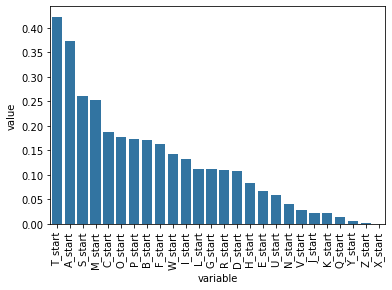

In [43]:
sns.barplot(
    data=puzzles[puzzles.Category.isin(["What Are You Doing?"])]
    .groupby("Category")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

_ = plt.xticks(rotation=90)

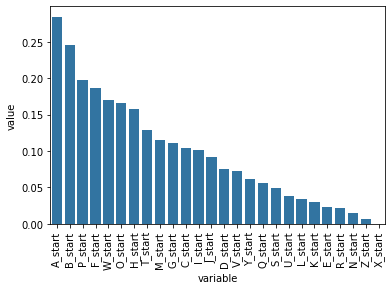

In [44]:
puzzles["test"] = 1
sns.barplot(
    data=puzzles[puzzles.Round.isin(["BR"])]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

_ = plt.xticks(rotation=90)


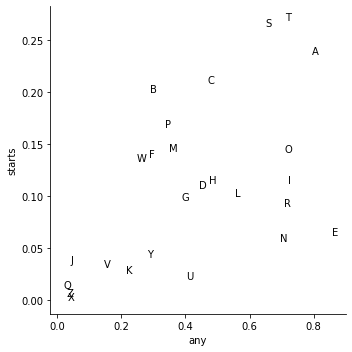

In [45]:
starts = (
    puzzles[puzzles.Category != "What Are You Doing?"]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles[puzzles.Category != "What Are You Doing?"]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    plt.text(r.any, r.starts, r.variable)

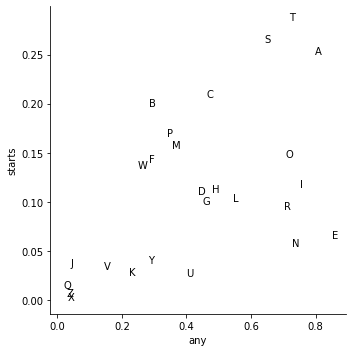

In [46]:
starts = (
    puzzles.groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles.groupby("test")
    
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    plt.text(r.any, r.starts, r.variable)

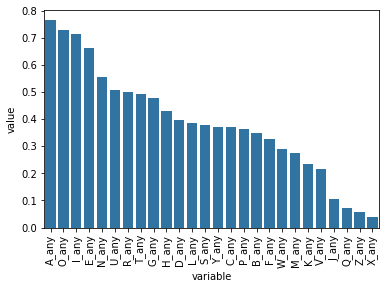

In [33]:
sns.barplot(
    data=puzzles[puzzles.Round.isin(["BR"])]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

_ = plt.xticks(rotation=90)


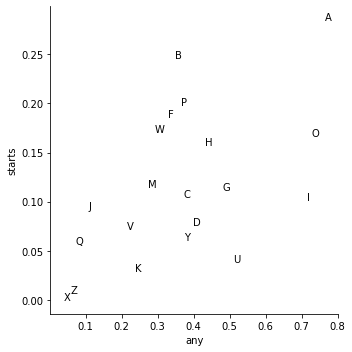

In [36]:
starts = (
    puzzles[puzzles.Round.isin(["BR"])] #& ~puzzles.Category.isin(["What Are You Doing?"])]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles[puzzles.Round.isin(["BR"])]# & ~puzzles.Category.isin(["What Are You Doing?"])]
    
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    if r.variable in "LSRTNE":
        continue
    plt.text(r.any, r.starts, r.variable)

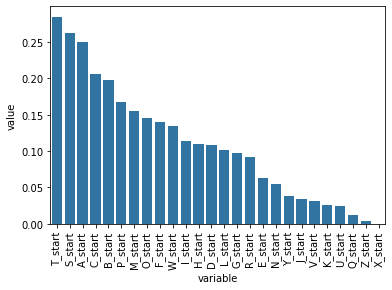

In [37]:
puzzles["test"] = 1
sns.barplot(
    data=puzzles.groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

_ = plt.xticks(rotation=90)


In [ ]:
puzzles[puzzles.Category.isin(puzzles.Category.value_counts().index[:50])].groupby("Category").mean(numeric_only=True)[
    [f"{l}_start" for l in letters]
].reset_index()[puzzles.Category.value_counts().index.values]

KeyError: "None of [Index(['Phrase', 'What Are You Doing?', 'Thing', 'Food & Drink', 'Place',\n       'Fun & Games', 'Event', 'Before & After', 'Person', 'Things',\n       ...\n       'Tennis _____', '_____ School', 'If the Shoe Fits', 'World Capitals',\n       'On the Water', '_____ Boat', 'Have A Cookie', 'Coastal _____',\n       'Artificial _____', 'Vehicles'],\n      dtype='object', length=712)] are in the [columns]"

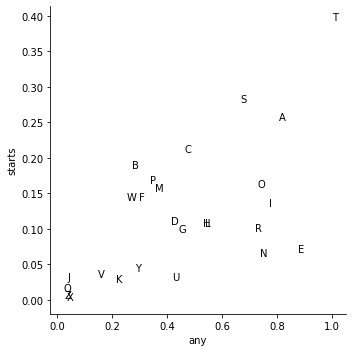

In [ ]:
starts = (
    puzzles[puzzles.T_any]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles[puzzles.T_any]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    plt.text(r.any, r.starts, r.variable)

In [15]:
# two letter frequency
means = []
for l in letters:
    for l2 in letters:
        means.append([l, l2,puzzles[f"{l+l2}_any"].mean(),puzzles[f"{l}_any"].mean(),puzzles[f"{l2}_any"].mean() ])


In [16]:
means_df = pd.DataFrame(means, columns=['l1','l2','bigram_mean','l1_mean','l2_mean'])

In [18]:
means_df['pct_increase'] = means_df['bigram_mean'] / means_df['l1_mean'] / means_df['l2_mean'] 

In [22]:
means_df.sort_values('bigram_mean',ascending=False).head(50)

,l1,l2,bigram_mean,l1_mean,l2_mean,pct_increase
221,I,N,0.367728,0.747230,0.728550,0.675481
344,N,G,0.273954,0.728550,0.446716,0.841757
121,E,R,0.245538,0.851481,0.703750,0.409757
501,T,H,0.217772,0.715988,0.478561,0.635564
13,A,N,0.206740,0.796922,0.728550,0.356081
186,H,E,0.204005,0.478561,0.851481,0.500643
377,O,N,0.175219,0.710703,0.728550,0.338403
446,R,E,0.170815,0.703750,0.851481,0.285058
17,A,R,0.157280,0.796922,0.703750,0.280439
487,S,T,0.153711,0.645158,0.715988,0.332761


In [23]:
means_df.sort_values('pct_increase',ascending=False).head(50)

,l1,l2,bigram_mean,l1_mean,l2_mean,pct_increase
675,Z,Z,0.005980,0.028693,0.028693,7.263049
436,Q,U,0.020674,0.020674,0.400779,2.495142
344,N,G,0.273954,0.728550,0.446716,0.841757
127,E,X,0.019701,0.851481,0.032587,0.710000
254,J,U,0.011310,0.041163,0.400779,0.685602
221,I,N,0.367728,0.747230,0.728550,0.675481
62,C,K,0.069021,0.466231,0.223196,0.663281
550,V,E,0.081166,0.148658,0.851481,0.641228
501,T,H,0.217772,0.715988,0.478561,0.635564
186,H,E,0.204005,0.478561,0.851481,0.500643


In [24]:
means_df.sort_values('pct_increase',ascending=False).head(50)

,l1,l2,bigram_mean,l1_mean,l2_mean,pct_increase
675,Z,Z,0.005980,0.028693,0.028693,7.263049
436,Q,U,0.020674,0.020674,0.400779,2.495142
344,N,G,0.273954,0.728550,0.446716,0.841757
127,E,X,0.019701,0.851481,0.032587,0.710000
254,J,U,0.011310,0.041163,0.400779,0.685602
221,I,N,0.367728,0.747230,0.728550,0.675481
62,C,K,0.069021,0.466231,0.223196,0.663281
550,V,E,0.081166,0.148658,0.851481,0.641228
501,T,H,0.217772,0.715988,0.478561,0.635564
186,H,E,0.204005,0.478561,0.851481,0.500643
